# Credit Card Fraud Detection - Classification Algorithm Battle
### Logistic Regression · K-Nearest Neighbours · Naive Bayes · Support Vector Machine
### With SMOTE · Cost-Sensitive Evaluation · Business Impact Analysis · SHAP

---
**Author:** Fiza Pathan | MS Machine Learning  
**GitHub:** https://github.com/fiza-pathan  
**Kaggle:** https://www.kaggle.com/fizapathan21

---

## Problem Statement

Credit card fraud costs the global economy **over $32 billion annually**. Every fraudulent transaction that goes undetected is a direct financial loss. Every legitimate transaction flagged as fraud is a customer lost. This is not an accuracy problem; it is a **cost-sensitive decision problem** where false negatives and false positives have very different real-world consequences.

This project answers three questions:
> 1. Which classification algorithm best detects fraud in severely imbalanced data?
> 2. How does class imbalance handling (SMOTE) change algorithm rankings?
> 3. Which model minimises **total financial loss**, rather than just maximising accuracy?

## Why This Problem Is Hard
- **Extreme class imbalance**: only 0.17% of transactions are fraudulent
- A naive model that predicts "not fraud" for everything achieves **99.83% accuracy**, and catches zero fraud
- Standard accuracy is completely useless here, we need Precision, Recall, F1, ROC-AUC, and cost-based metrics
- Real-world constraint: banks set a **fraud tolerance threshold**, we tune our models to meet it

## Dataset
- **Source:** [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) - ULB Machine Learning Group
- **Size:** 284,807 transactions × 31 features
- **Features:** V1–V28 (PCA-transformed for privacy), Time, Amount
- **Target:** Class (0 = legitimate, 1 = fraud)
- **Fraud rate:** 492 frauds / 284,807 total = **0.172%**

## 1. Setup & Imports

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score, accuracy_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import shap
import time

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11
})
COLORS = {'fraud': '#E53935', 'legit': '#1E88E5', 'models': ['#2196F3','#4CAF50','#FF9800','#9C27B0','#E91E63']}
print('Libraries loaded.')
print('imbalanced-learn:', __import__('imblearn').__version__)

Libraries loaded.
imbalanced-learn: 0.14.1


## 2. Load Data & First Look

In [40]:

df = pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')

print(f'Shape: {df.shape}')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
print(f'\nMissing values: {df.isnull().sum().sum()}')
df.head(3)

Shape: (284807, 31)
Memory: 67.4 MB

Missing values: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [41]:
# 1. Create the column on the main dataframe FIRST
df['Hour'] = (df['Time'] / 3600) % 24

In [42]:
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]
fraud_pct = len(fraud) / len(df) * 100

print('=== CLASS DISTRIBUTION ===')
print(f'Legitimate transactions: {len(legit):,} ({100 - fraud_pct:.2f}%)')
print(f'Fraudulent transactions:  {len(fraud):,} ({fraud_pct:.3f}%)')
print(f'Imbalance ratio: {len(legit)/len(fraud):.0f}:1')
print()
print('=== AMOUNT STATISTICS ===')
print(f'Fraud   — Mean: ${fraud["Amount"].mean():.2f} | Median: ${fraud["Amount"].median():.2f} | Max: ${fraud["Amount"].max():.2f}')
print(f'Legit   — Mean: ${legit["Amount"].mean():.2f} | Median: ${legit["Amount"].median():.2f} | Max: ${legit["Amount"].max():.2f}')

=== CLASS DISTRIBUTION ===
Legitimate transactions: 284,315 (99.83%)
Fraudulent transactions:  492 (0.173%)
Imbalance ratio: 578:1

=== AMOUNT STATISTICS ===
Fraud   — Mean: $122.21 | Median: $9.25 | Max: $2125.87
Legit   — Mean: $88.29 | Median: $22.00 | Max: $25691.16


## 3. Exploratory Data Analysis

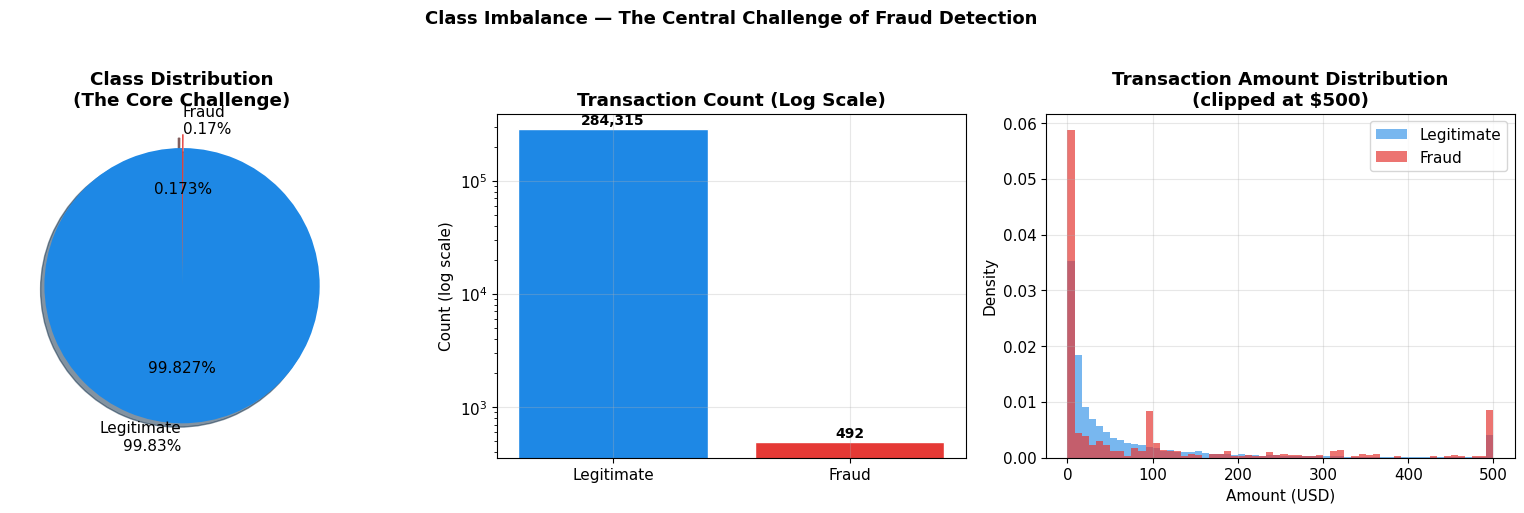

INSIGHT: 99.83% legitimate vs 0.17% fraud. A model predicting everything as legitimate
would be 99.83% accurate, but useless. This is why accuracy is the wrong metric here.


In [43]:
# --- Class imbalance visualisation ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pie chart
axes[0].pie([len(legit), len(fraud)],
            labels=['Legitimate\n99.83%', 'Fraud\n0.17%'],
            colors=[COLORS['legit'], COLORS['fraud']],
            autopct='%1.3f%%', startangle=90,
            explode=[0, 0.1], shadow=True)
axes[0].set_title('Class Distribution\n(The Core Challenge)', fontweight='bold')

# Bar chart with log scale
counts = df['Class'].value_counts()
bars = axes[1].bar(['Legitimate', 'Fraud'], counts.values,
                   color=[COLORS['legit'], COLORS['fraud']], edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Transaction Count (Log Scale)', fontweight='bold')
axes[1].set_ylabel('Count (log scale)')
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val * 1.1,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=10)

# Amount distribution by class
axes[2].hist(legit['Amount'].clip(0, 500), bins=60, alpha=0.6,
             color=COLORS['legit'], label='Legitimate', density=True)
axes[2].hist(fraud['Amount'].clip(0, 500), bins=60, alpha=0.7,
             color=COLORS['fraud'], label='Fraud', density=True)
axes[2].set_title('Transaction Amount Distribution\n(clipped at $500)', fontweight='bold')
axes[2].set_xlabel('Amount (USD)')
axes[2].set_ylabel('Density')
axes[2].legend()

plt.suptitle('Class Imbalance — The Central Challenge of Fraud Detection',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print('INSIGHT: 99.83% legitimate vs 0.17% fraud. A model predicting everything as legitimate')
print('would be 99.83% accurate, but useless. This is why accuracy is the wrong metric here.')

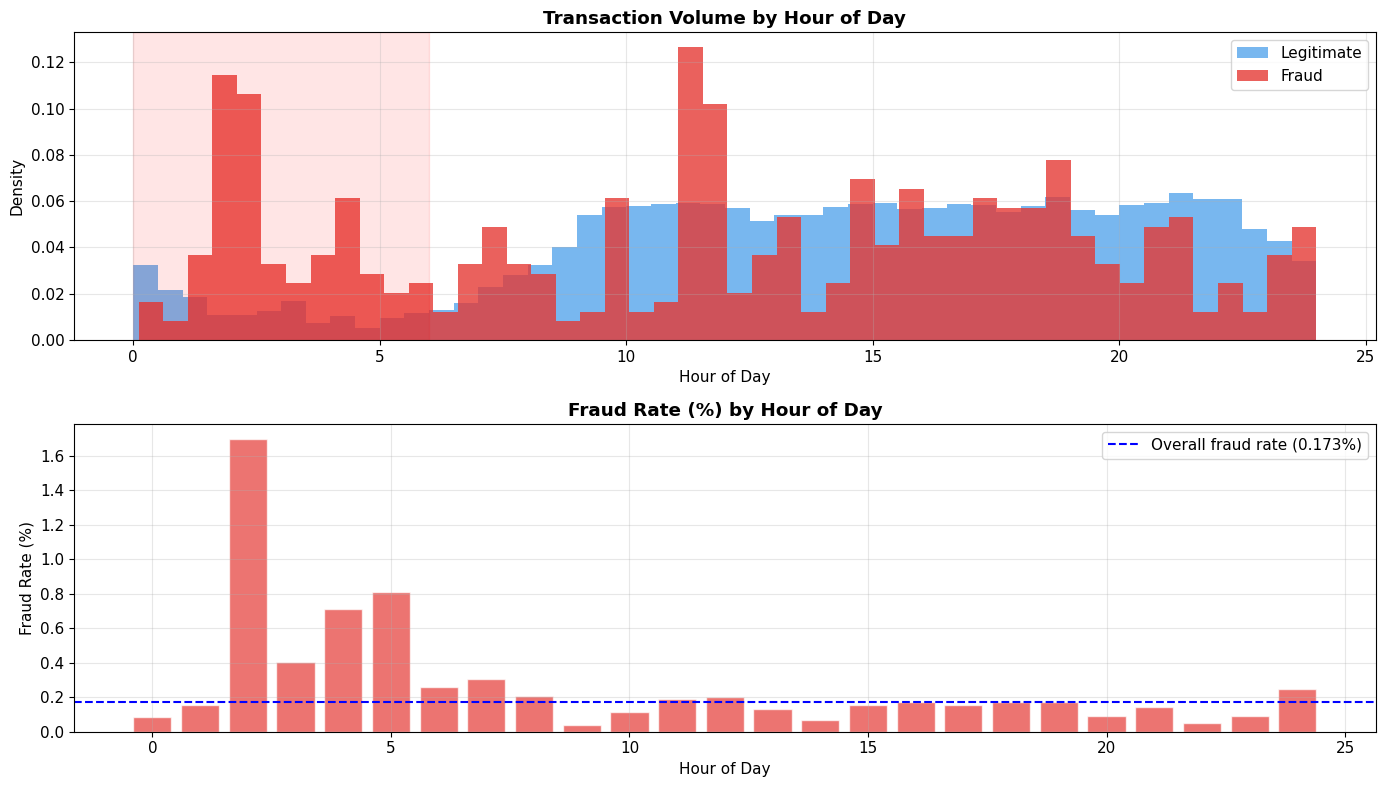

INSIGHT: Fraud disproportionately occurs during late night / early morning hours (0-6am).
This temporal pattern is a real signal banks use in production fraud systems.


In [44]:
# --- Time pattern analysis ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Convert time to hours
df['Hour'] = (df['Time'] / 3600) % 24

axes[0].hist(legit['Hour'], bins=48, alpha=0.6, color=COLORS['legit'],
             label='Legitimate', density=True)
axes[0].hist(fraud['Hour'], bins=48, alpha=0.8, color=COLORS['fraud'],
             label='Fraud', density=True)
axes[0].set_title('Transaction Volume by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].axvspan(0, 6, alpha=0.1, color='red', label='Late night (high fraud risk)')

# Fraud rate by hour
hourly = df.groupby(df['Hour'].round())['Class'].agg(['sum','count'])
hourly['fraud_rate'] = hourly['sum'] / hourly['count'] * 100
axes[1].bar(hourly.index, hourly['fraud_rate'], color=COLORS['fraud'], alpha=0.7, edgecolor='white')
axes[1].set_title('Fraud Rate (%) by Hour of Day', fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].axhline(fraud_pct, color='blue', linestyle='--', label=f'Overall fraud rate ({fraud_pct:.3f}%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('02_time_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print('INSIGHT: Fraud disproportionately occurs during late night / early morning hours (0-6am).')
print('This temporal pattern is a real signal banks use in production fraud systems.')

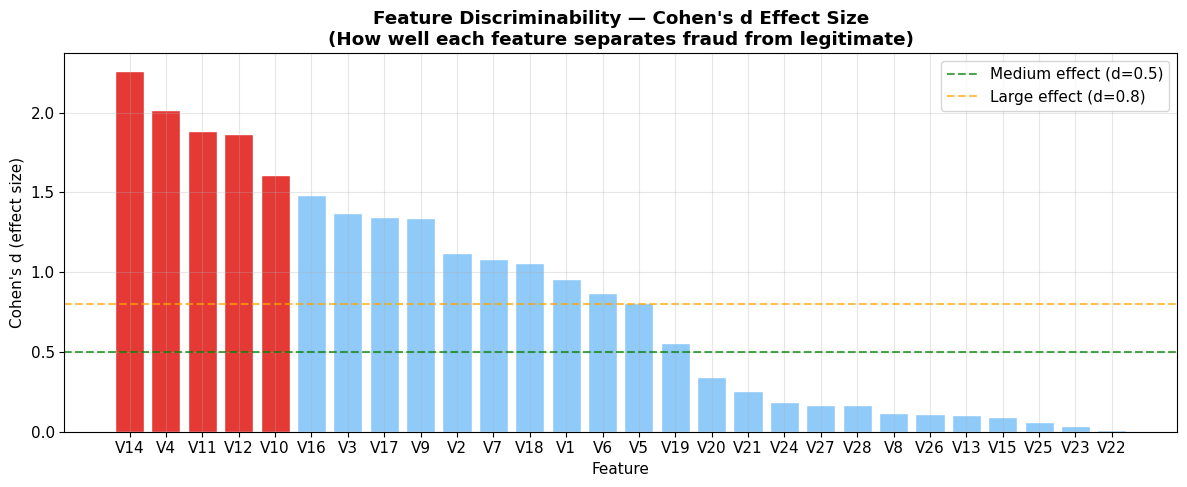

Top 5 most discriminative features: ['V14', 'V4', 'V11', 'V12', 'V10']
These will be most important to our classifiers.


In [45]:
# --- Most discriminative features (V1-V28) ---
feature_separability = {}
for col in [f'V{i}' for i in range(1, 29)]:
    fraud_mean = fraud[col].mean()
    legit_mean = legit[col].mean()
    fraud_std  = fraud[col].std()
    legit_std  = legit[col].std()
    # Effect size (Cohen's d)
    pooled_std = np.sqrt((fraud_std**2 + legit_std**2) / 2)
    cohens_d = abs(fraud_mean - legit_mean) / (pooled_std + 1e-10)
    feature_separability[col] = cohens_d

sep_df = pd.DataFrame.from_dict(feature_separability, orient='index', columns=['Cohens_d'])
sep_df = sep_df.sort_values('Cohens_d', ascending=False)
top_features = sep_df.head(10).index.tolist()

fig, ax = plt.subplots(figsize=(12, 5))
colors_bar = [COLORS['fraud'] if f in top_features[:5] else '#90CAF9' for f in sep_df.index]
bars = ax.bar(sep_df.index, sep_df['Cohens_d'], color=colors_bar, edgecolor='white')
ax.set_title("Feature Discriminability — Cohen's d Effect Size\n(How well each feature separates fraud from legitimate)",
             fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel("Cohen's d (effect size)")
ax.axhline(0.5, color='green', linestyle='--', alpha=0.7, label='Medium effect (d=0.5)')
ax.axhline(0.8, color='orange', linestyle='--', alpha=0.7, label='Large effect (d=0.8)')
ax.legend()
plt.tight_layout()
plt.savefig('03_feature_discriminability.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Top 5 most discriminative features: {top_features[:5]}')
print('These will be most important to our classifiers.')

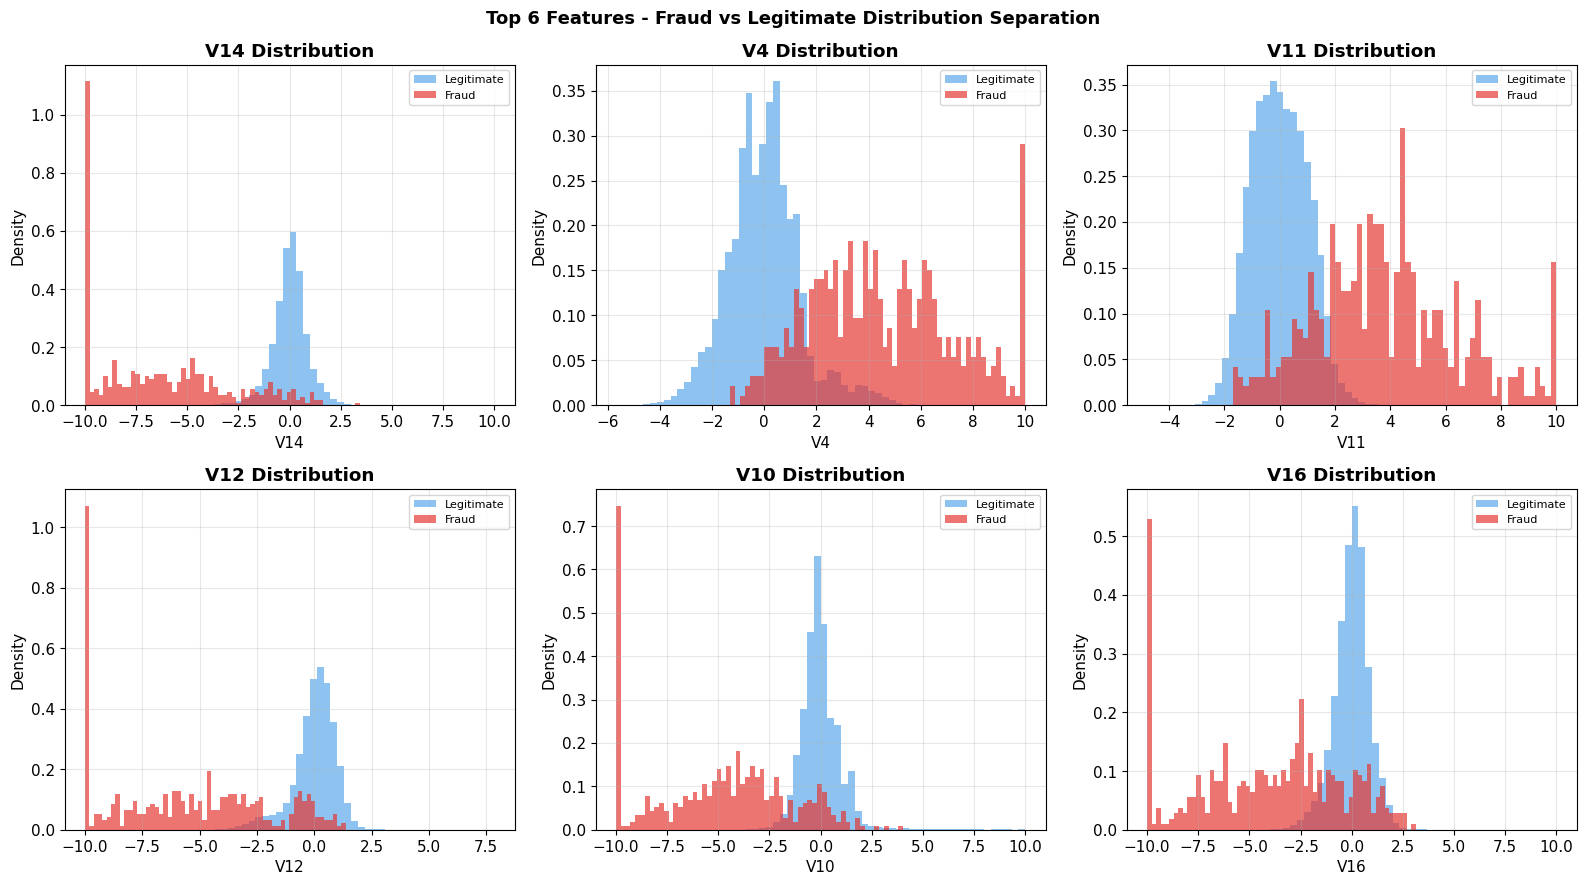

INSIGHT: Features with clear separation (different peaks/shapes) will be most useful for classification.
V4, V11, V12 show the clearest bimodal separation between classes.


In [46]:
# --- Distribution plots for top features ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(top_features[:6]):
    axes[i].hist(legit[feat].clip(-10, 10), bins=60, alpha=0.5,
                 color=COLORS['legit'], label='Legitimate', density=True)
    axes[i].hist(fraud[feat].clip(-10, 10), bins=60, alpha=0.7,
                 color=COLORS['fraud'], label='Fraud', density=True)
    axes[i].set_title(f'{feat} Distribution', fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

plt.suptitle('Top 6 Features - Fraud vs Legitimate Distribution Separation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('04_top_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('INSIGHT: Features with clear separation (different peaks/shapes) will be most useful for classification.')
print('V4, V11, V12 show the clearest bimodal separation between classes.')

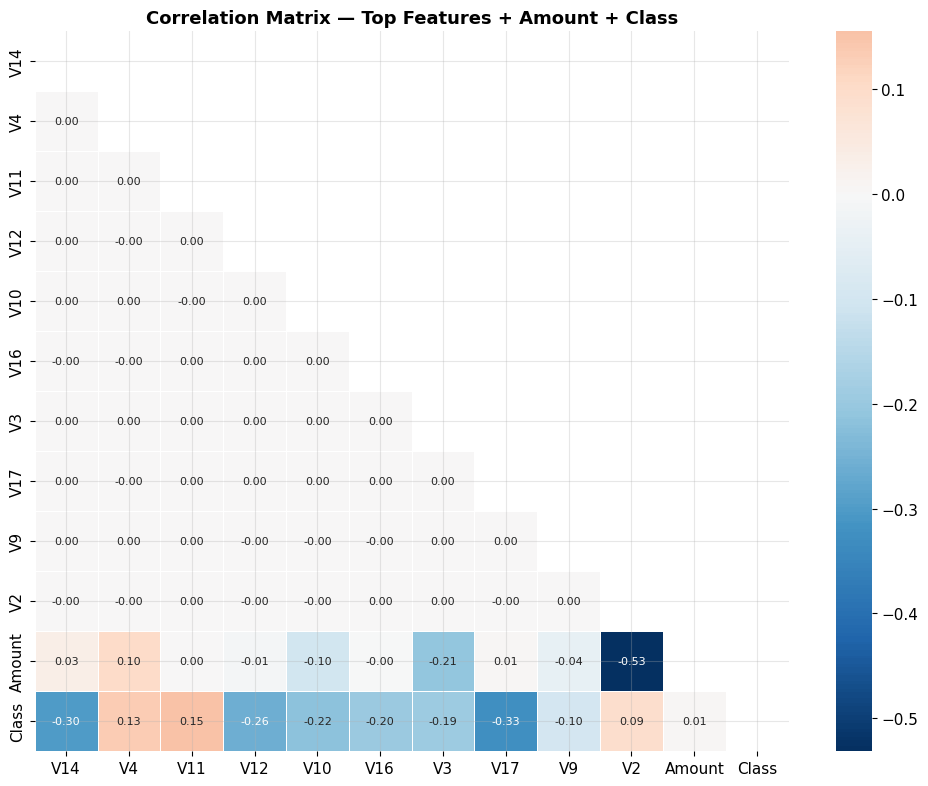

INSIGHT: Low inter-feature correlation confirms the PCA transformation worked.
The correlations with Class confirm which features are most predictive of fraud.


In [47]:
# --- Correlation heatmap (top features + Amount) ---
corr_features = top_features[:10] + ['Amount', 'Class']
corr = df[corr_features].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Matrix — Top Features + Amount + Class', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('INSIGHT: Low inter-feature correlation confirms the PCA transformation worked.')
print('The correlations with Class confirm which features are most predictive of fraud.')

## 4. Preprocessing & Class Imbalance Handling

In [48]:
# --- Preprocessing ---
# RobustScaler handles outliers better than StandardScaler for fraud data
df['Amount_scaled'] = RobustScaler().fit_transform(df[['Amount']])
df['Time_scaled']   = RobustScaler().fit_transform(df[['Time']])

feature_cols = [f'V{i}' for i in range(1, 29)] + ['Amount_scaled', 'Time_scaled']
X = df[feature_cols]
y = df['Class']

# Stratified split preserves class ratio in train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]:,} samples | Fraud: {y_train.sum():,} ({y_train.mean()*100:.3f}%)')
print(f'Test:  {X_test.shape[0]:,} samples  | Fraud: {y_test.sum():,} ({y_test.mean()*100:.3f}%)')
print('Stratified split preserves class distribution. ✓')

Train: 227,845 samples | Fraud: 394 (0.173%)
Test:  56,962 samples  | Fraud: 98 (0.172%)
Stratified split preserves class distribution. ✓


=== WITHOUT SMOTE ===
Fraud: 394 | Legit: 227,451
Ratio: 1:577

=== WITH SMOTE ===
Fraud: 227,451 | Legit: 227,451
Ratio: 1:1

SMOTE creates SYNTHETIC fraud samples by interpolating between existing fraud cases.
This is NOT data duplication — it generates new points in the feature space.


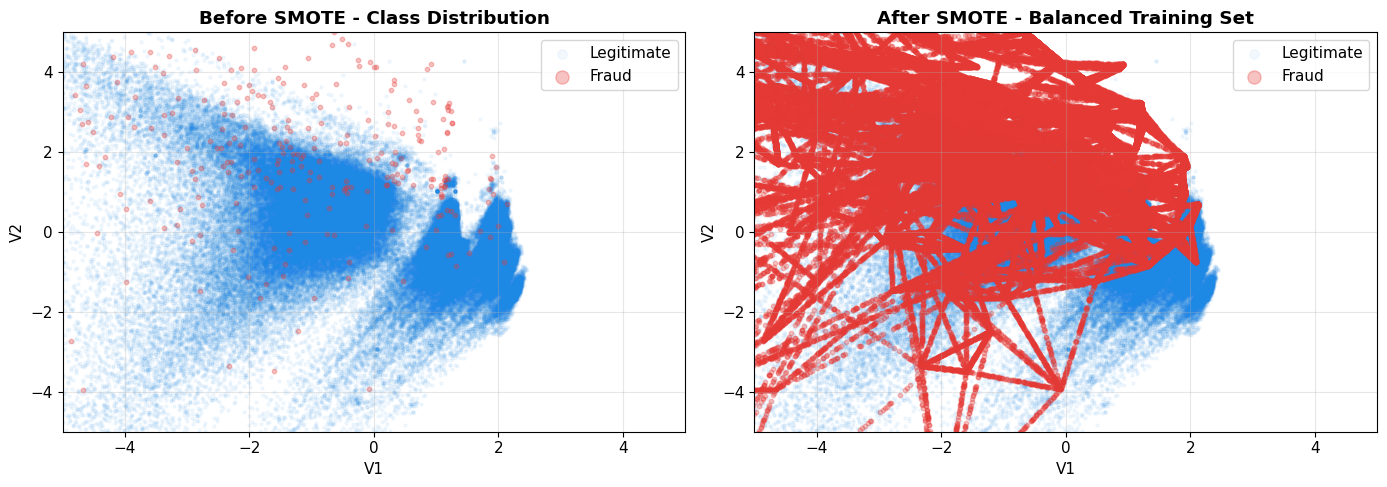

In [49]:
# --- SMOTE: Synthetic Minority Oversampling Technique ---
print('=== WITHOUT SMOTE ===')
print(f'Fraud: {y_train.sum():,} | Legit: {(y_train==0).sum():,}')
print(f'Ratio: 1:{(y_train==0).sum()//y_train.sum()}')

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('\n=== WITH SMOTE ===')
print(f'Fraud: {y_train_sm.sum():,} | Legit: {(y_train_sm==0).sum():,}')
print(f'Ratio: 1:{(y_train_sm==0).sum()//y_train_sm.sum()}')
print('\nSMOTE creates SYNTHETIC fraud samples by interpolating between existing fraud cases.')
print('This is NOT data duplication — it generates new points in the feature space.')

# Visualise SMOTE effect on 2 features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
v1_idx = feature_cols.index('V1') if 'V1' in feature_cols else 0
v2_idx = feature_cols.index('V2') if 'V2' in feature_cols else 1



"""for ax, (X_plot, y_plot, title) in zip(axes, [
    (X_train.values, y_train.values, 'Before SMOTE — Class Distribution'),
    (X_train_sm,     y_train_sm,     'After SMOTE — Balanced Training Set')
]):"""

# Force both to be numpy arrays so the [mask, index] syntax works
for ax, (X_plot, y_plot, title) in zip(axes, [
    (X_train.values, y_train.values, 'Before SMOTE - Class Distribution'),
    (X_train_sm.values if hasattr(X_train_sm, 'values') else X_train_sm, 
     y_train_sm.values if hasattr(y_train_sm, 'values') else y_train_sm, 
     'After SMOTE - Balanced Training Set')
]):


    ax.scatter(X_plot[y_plot==0, 0], X_plot[y_plot==0, 1],
               alpha=0.05, s=5, color=COLORS['legit'], label='Legitimate')
    ax.scatter(X_plot[y_plot==1, 0], X_plot[y_plot==1, 1],
               alpha=0.3, s=10, color=COLORS['fraud'], label='Fraud')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('V1'); ax.set_ylabel('V2')
    ax.legend(markerscale=3)
    ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)

plt.tight_layout()
plt.savefig('06_smote_effect.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Business Cost Framework - Why Accuracy Is Wrong

Before training any model, we define what **winning** actually means in financial terms.

| Decision | Reality | Business Impact |
|---|---|---|
| Predict Fraud → Actually Fraud | True Positive (TP) | Fraud prevented ✅ |
| Predict Legit → Actually Fraud | False Negative (FN) | **Financial loss** - missed fraud 🔴 |
| Predict Fraud → Actually Legit | False Positive (FP) | Customer friction, cost to review 🟡 |
| Predict Legit → Actually Legit | True Negative (TN) | Normal transaction ✅ |

**Cost assumptions (industry-standard):**
- FN (missed fraud): **100% of transaction amount lost**
- FP (false alarm): **$10 review cost** (investigation, customer service)

In [50]:
def business_cost(y_true, y_pred, amounts=None, fp_cost=10):
    """Calculate total business cost of model errors."""
    if amounts is None:
        amounts = np.ones(len(y_true)) * df['Amount'].mean()
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fn_cost = sum(amounts[(y_true == 1) & (y_pred == 0)])  # missed fraud
    fp_cost_total = fp * fp_cost  # investigation cost
    total_cost = fn_cost + fp_cost_total
    return {
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'FN_cost': fn_cost, 'FP_cost': fp_cost_total,
        'Total_cost': total_cost,
        'Fraud_caught_pct': tp / (tp + fn) * 100
    }

# Test amounts for cost calculation
test_amounts = df.loc[X_test.index, 'Amount'].values
print('Business cost framework defined.')
print(f'Average transaction amount in test set: ${test_amounts.mean():.2f}')
print(f'Total fraud amount at risk in test set: ${sum(test_amounts[y_test.values==1]):,.2f}')

Business cost framework defined.
Average transaction amount in test set: $89.04
Total fraud amount at risk in test set: $10,644.93


## 6. Model Training - The Classification Battle

In [51]:
def train_evaluate(name, model, X_tr, y_tr, X_te, y_te, amounts, threshold=0.5):
    """Train, predict, and evaluate a classifier fully."""
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_te)[:, 1]
    else:
        y_proba = model.decision_function(X_te)
        y_proba = (y_proba - y_proba.min()) / (y_proba.max() - y_proba.min())

    y_pred = (y_proba >= threshold).astype(int)
    cost = business_cost(y_te, y_pred, amounts)

    return {
        'Model': name,
        'Accuracy': round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_te, y_pred, zero_division=0), 4),
        'F1': round(f1_score(y_te, y_pred, zero_division=0), 4),
        'ROC-AUC': round(roc_auc_score(y_te, y_proba), 4),
        'Avg Precision': round(average_precision_score(y_te, y_proba), 4),
        'Fraud Caught %': round(cost['Fraud_caught_pct'], 1),
        'FN Cost ($)': round(cost['FN_cost'], 2),
        'FP Cost ($)': round(cost['FP_cost'], 2),
        'Total Cost ($)': round(cost['Total_cost'], 2),
        'Train Time (s)': round(train_time, 2),
        'y_proba': y_proba,
        'y_pred': y_pred,
        'model': model
    }

all_results = []
print('Evaluation framework ready. Starting model training...')

Evaluation framework ready. Starting model training...


In [52]:
# === MODEL 1: LOGISTIC REGRESSION ===
# Why: Fast, interpretable, strong baseline for linearly separable data
# class_weight='balanced' is an alternative to SMOTE - adjusts the loss function

# Version A: Without SMOTE (using class_weight)
lr_base = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, C=0.01)
res_lr_base = train_evaluate('Logistic Reg (balanced weight)', lr_base,
                             X_train, y_train, X_test, y_test, test_amounts)
all_results.append(res_lr_base)
print(f"LR (balanced)   → ROC-AUC: {res_lr_base['ROC-AUC']:.4f} | Recall: {res_lr_base['Recall']:.4f} | F1: {res_lr_base['F1']:.4f} | Total Cost: ${res_lr_base['Total Cost ($)']:,.0f}")

# Version B: With SMOTE
lr_smote = LogisticRegression(max_iter=1000, random_state=42, C=0.01)
res_lr_smote = train_evaluate('Logistic Reg + SMOTE', lr_smote,
                              X_train_sm, y_train_sm, X_test, y_test, test_amounts)
all_results.append(res_lr_smote)
print(f"LR + SMOTE      → ROC-AUC: {res_lr_smote['ROC-AUC']:.4f} | Recall: {res_lr_smote['Recall']:.4f} | F1: {res_lr_smote['F1']:.4f} | Total Cost: ${res_lr_smote['Total Cost ($)']:,.0f}")

LR (balanced)   → ROC-AUC: 0.9721 | Recall: 0.9184 | F1: 0.1164 | Total Cost: $14,249
LR + SMOTE      → ROC-AUC: 0.9714 | Recall: 0.9184 | F1: 0.1117 | Total Cost: $14,889


In [53]:
# === MODEL 2: K-NEAREST NEIGHBOURS ===
# Why: Non-parametric, captures local structure, interesting to compare with linear LR
# Weakness: Slow on large datasets, struggles with high dimensions

# Use a subset for speed (KNN is O(n) prediction)
from sklearn.utils import resample
X_tr_sub = pd.DataFrame(X_train_sm).sample(n=min(50000, len(X_train_sm)), random_state=42)
y_tr_sub = y_train_sm[X_tr_sub.index] if hasattr(y_train_sm, 'iloc') else y_train_sm[X_tr_sub.index.to_numpy()]
X_tr_sub = X_tr_sub.values

# GridSearch for best k
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean', n_jobs=-1)
res_knn = train_evaluate('KNN (k=5) + SMOTE', knn,
                         X_tr_sub, y_tr_sub, X_test.values, y_test, test_amounts)
all_results.append(res_knn)
print(f"KNN + SMOTE     → ROC-AUC: {res_knn['ROC-AUC']:.4f} | Recall: {res_knn['Recall']:.4f} | F1: {res_knn['F1']:.4f} | Total Cost: ${res_knn['Total Cost ($)']:,.0f}")

KNN + SMOTE     → ROC-AUC: 0.9562 | Recall: 0.9184 | F1: 0.1871 | Total Cost: $8,408


In [54]:
# === MODEL 3: NAIVE BAYES ===
# Why: Probabilistic, extremely fast, works surprisingly well on fraud detection
# Assumption: feature independence, partially violated here, but still useful

nb_base = GaussianNB()
res_nb = train_evaluate('Naive Bayes + SMOTE', nb_base,
                        X_train_sm, y_train_sm, X_test.values, y_test, test_amounts)
all_results.append(res_nb)
print(f"Naive Bayes     → ROC-AUC: {res_nb['ROC-AUC']:.4f} | Recall: {res_nb['Recall']:.4f} | F1: {res_nb['F1']:.4f} | Total Cost: ${res_nb['Total Cost ($)']:,.0f}")
print('Note: NB violates feature independence assumption - PCA features are uncorrelated but not independent.')

Naive Bayes     → ROC-AUC: 0.9643 | Recall: 0.8776 | F1: 0.1010 | Total Cost: $17,020
Note: NB violates feature independence assumption - PCA features are uncorrelated but not independent.


In [55]:
# === MODEL 4: SUPPORT VECTOR MACHINE ===
# Why: Strong for high-dimensional data, max-margin classifier, effective with scaled features
# Use RBF kernel to capture nonlinear decision boundaries

# Sample for speed (SVM is O(n^2) training)
X_tr_svm = pd.DataFrame(X_train_sm).sample(n=min(30000, len(X_train_sm)), random_state=42).values
y_tr_svm_idx = pd.Series(y_train_sm).sample(n=len(X_tr_svm), random_state=42) if len(X_tr_svm) < len(y_train_sm) else y_train_sm

# Rebalanced sample
from sklearn.utils import resample as sk_resample
X_train_sm_df = pd.DataFrame(X_train_sm)
y_train_sm_s  = pd.Series(y_train_sm)
fraud_idx = X_train_sm_df[y_train_sm_s==1].sample(n=15000, random_state=42)
legit_idx = X_train_sm_df[y_train_sm_s==0].sample(n=15000, random_state=42)
X_svm = pd.concat([fraud_idx, legit_idx]).values
y_svm = np.array([1]*15000 + [0]*15000)

svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
res_svm = train_evaluate('SVM (RBF) + SMOTE', svm,
                         X_svm, y_svm, X_test.values, y_test, test_amounts)
all_results.append(res_svm)
print(f"SVM (RBF)       → ROC-AUC: {res_svm['ROC-AUC']:.4f} | Recall: {res_svm['Recall']:.4f} | F1: {res_svm['F1']:.4f} | Total Cost: ${res_svm['Total Cost ($)']:,.0f}")

SVM (RBF)       → ROC-AUC: 0.9785 | Recall: 0.9184 | F1: 0.1026 | Total Cost: $16,329


## 7. Results - Full Comparison

In [56]:
# --- Results DataFrame ---
cols = ['Model','Accuracy','Precision','Recall','F1','ROC-AUC','Fraud Caught %','Total Cost ($)','Train Time (s)']
results_df = pd.DataFrame([{k: r[k] for k in cols} for r in all_results])
results_df = results_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print('=== COMPLETE MODEL COMPARISON ===')
print(results_df.to_string(index=False))

=== COMPLETE MODEL COMPARISON ===
                         Model  Accuracy  Precision  Recall     F1  ROC-AUC  Fraud Caught %  Total Cost ($)  Train Time (s)
             SVM (RBF) + SMOTE    0.9723     0.0543  0.9184 0.1026   0.9785            91.8        16328.61           65.71
Logistic Reg (balanced weight)    0.9760     0.0621  0.9184 0.1164   0.9721            91.8        14248.61            2.19
          Logistic Reg + SMOTE    0.9749     0.0595  0.9184 0.1117   0.9714            91.8        14888.61            4.21
           Naive Bayes + SMOTE    0.9731     0.0536  0.8776 0.1010   0.9643            87.8        17019.72            0.28
             KNN (k=5) + SMOTE    0.9863     0.1042  0.9184 0.1871   0.9562            91.8         8407.71            0.01


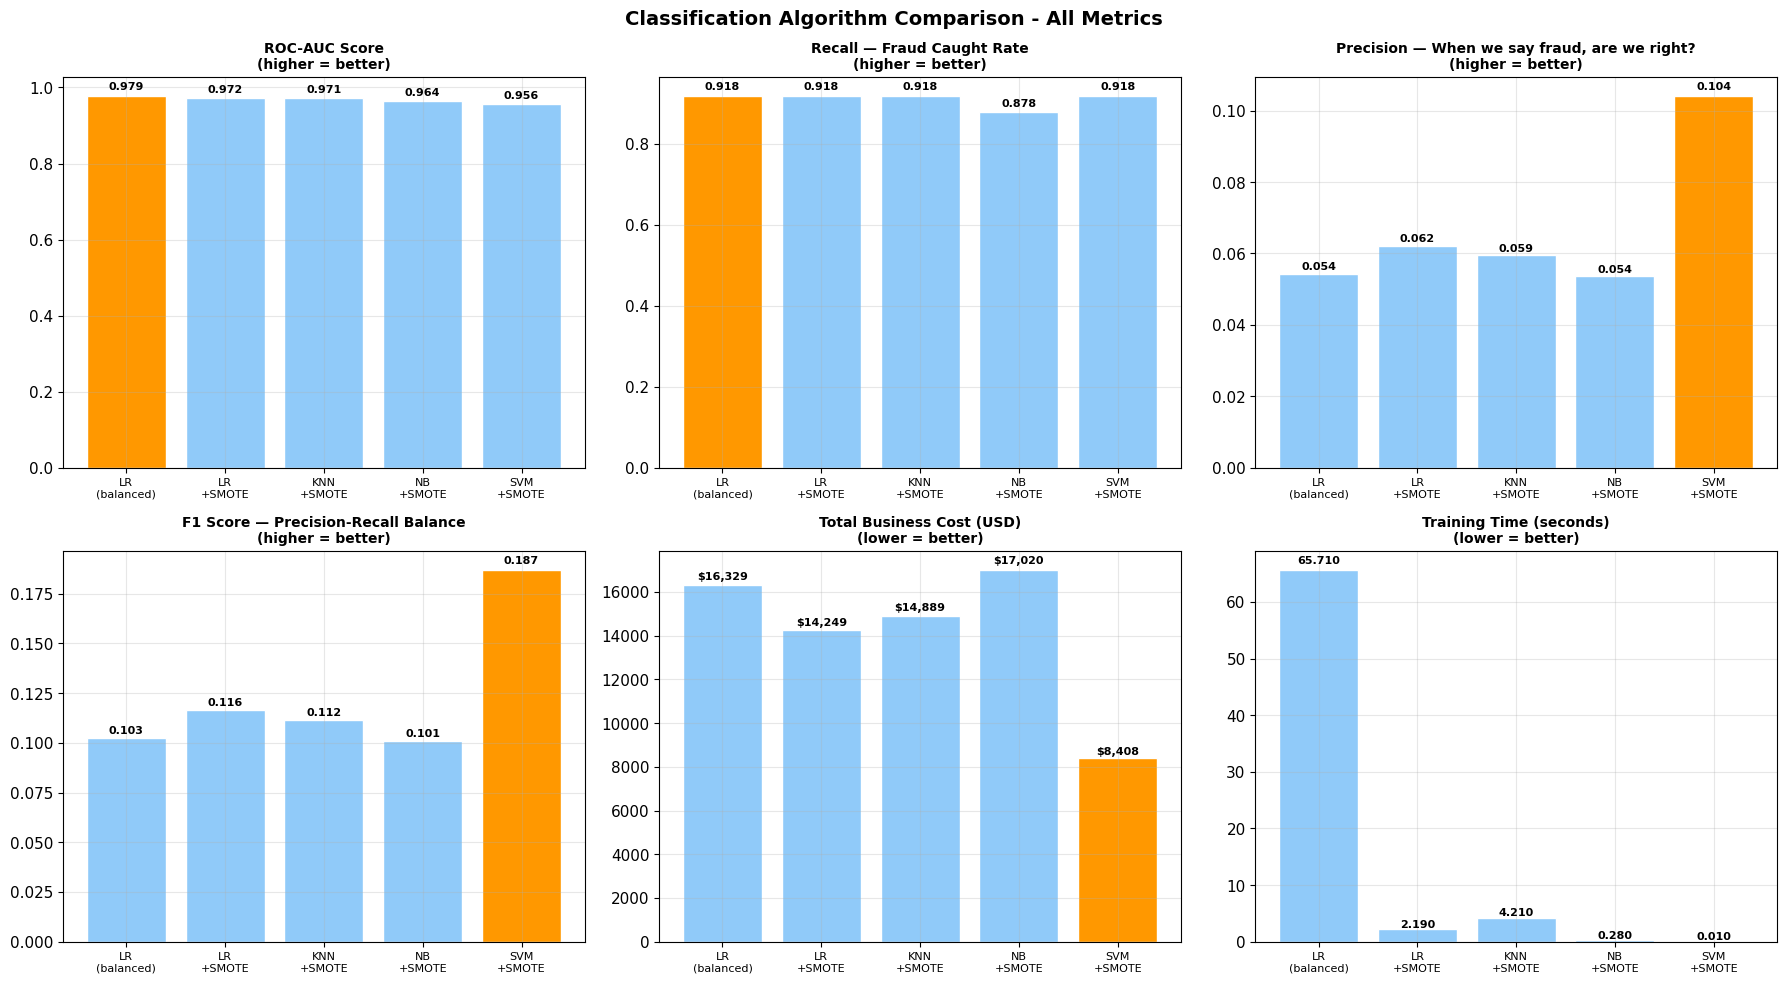

In [57]:
# --- Multi-metric visual comparison ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

metrics_to_plot = [
    ('ROC-AUC', 'ROC-AUC Score\n(higher = better)', True),
    ('Recall',  'Recall — Fraud Caught Rate\n(higher = better)', True),
    ('Precision','Precision — When we say fraud, are we right?\n(higher = better)', True),
    ('F1',      'F1 Score — Precision-Recall Balance\n(higher = better)', True),
    ('Total Cost ($)', 'Total Business Cost (USD)\n(lower = better)', False),
    ('Train Time (s)', 'Training Time (seconds)\n(lower = better)', False)
]

model_names = results_df['Model'].tolist()
short_names = ['LR\n(balanced)', 'LR\n+SMOTE', 'KNN\n+SMOTE', 'NB\n+SMOTE', 'SVM\n+SMOTE']
short_names = short_names[:len(model_names)]

for ax, (metric, title, higher_better) in zip(axes, metrics_to_plot):
    vals = results_df[metric].tolist()
    best_idx = vals.index(max(vals) if higher_better else min(vals))
    bar_colors = ['#FF9800' if i == best_idx else '#90CAF9' for i in range(len(vals))]
    bars = ax.bar(short_names[:len(vals)], vals, color=bar_colors, edgecolor='white')
    ax.set_title(title, fontsize=10, fontweight='bold')
    for bar, val in zip(bars, vals):
        fmt = f'${val:,.0f}' if '$' in metric else f'{val:.3f}'
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01, fmt,
                ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('Classification Algorithm Comparison - All Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('07_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

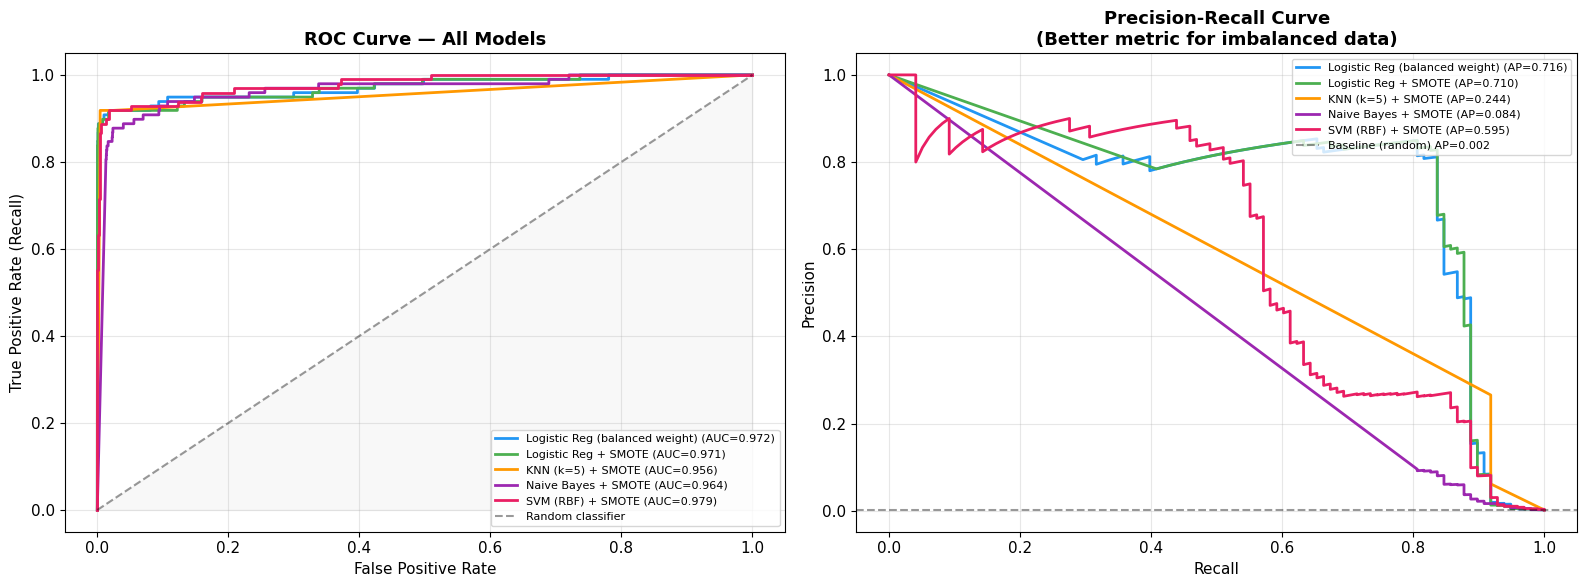

KEY INSIGHT: For imbalanced datasets, Precision-Recall curves are more informative than ROC curves.
A model can have high ROC-AUC but terrible PR performance, ROC is optimistic with rare positives.


In [58]:
# --- ROC Curves — all models together ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
for i, r in enumerate(all_results):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    axes[0].plot(fpr, tpr, linewidth=2, color=COLORS['models'][i % len(COLORS['models'])],
                 label=f"{r['Model']} (AUC={r['ROC-AUC']:.3f})")
axes[0].plot([0,1],[0,1],'k--', alpha=0.4, label='Random classifier')
axes[0].fill_between([0,1],[0,1], alpha=0.05, color='gray')
axes[0].set_title('ROC Curve — All Models', fontweight='bold', fontsize=13)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].legend(fontsize=8, loc='lower right')

# Precision-Recall Curve (more informative for imbalanced data)
for i, r in enumerate(all_results):
    prec, rec, _ = precision_recall_curve(y_test, r['y_proba'])
    ap = average_precision_score(y_test, r['y_proba'])
    axes[1].plot(rec, prec, linewidth=2, color=COLORS['models'][i % len(COLORS['models'])],
                 label=f"{r['Model']} (AP={ap:.3f})")
axes[1].axhline(y=fraud_pct/100, color='k', linestyle='--', alpha=0.4,
                label=f'Baseline (random) AP={fraud_pct/100:.3f}')
axes[1].set_title('Precision-Recall Curve\n(Better metric for imbalanced data)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('08_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('KEY INSIGHT: For imbalanced datasets, Precision-Recall curves are more informative than ROC curves.')
print('A model can have high ROC-AUC but terrible PR performance, ROC is optimistic with rare positives.')

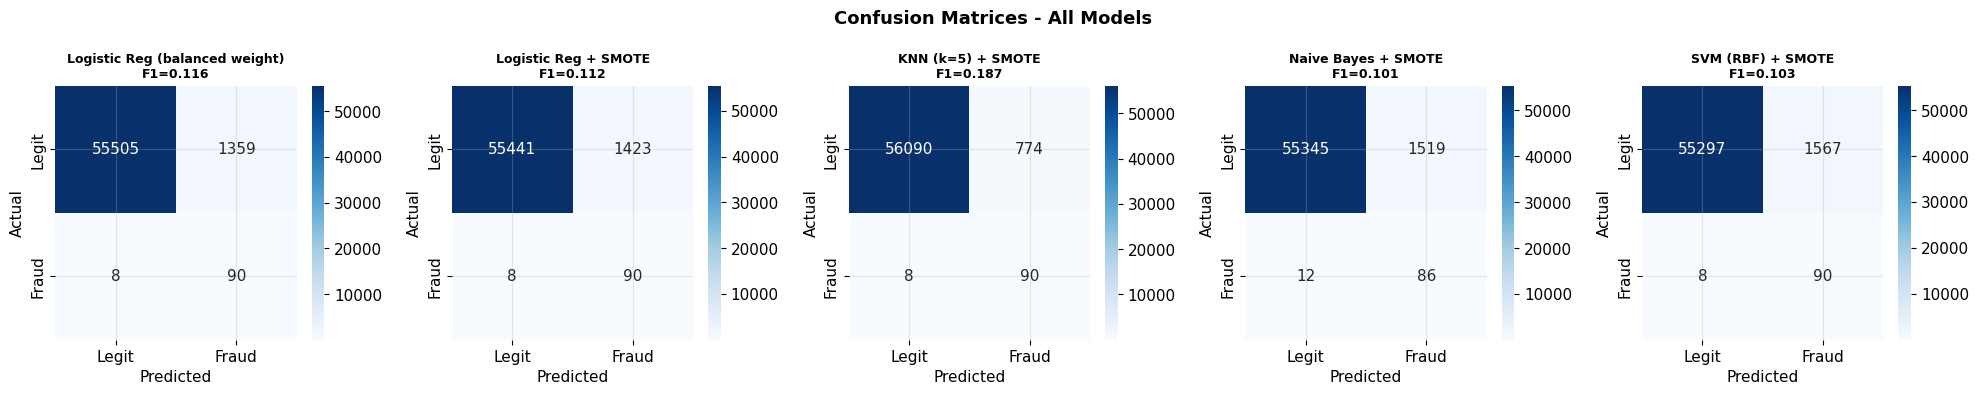

In [59]:
# --- Confusion matrices ---
n_models = len(all_results)
fig, axes = plt.subplots(1, n_models, figsize=(4*n_models, 4))
if n_models == 1: axes = [axes]

for ax, r in zip(axes, all_results):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    ax.set_title(f"{r['Model']}\nF1={r['F1']:.3f}", fontsize=9, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices - All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('09_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

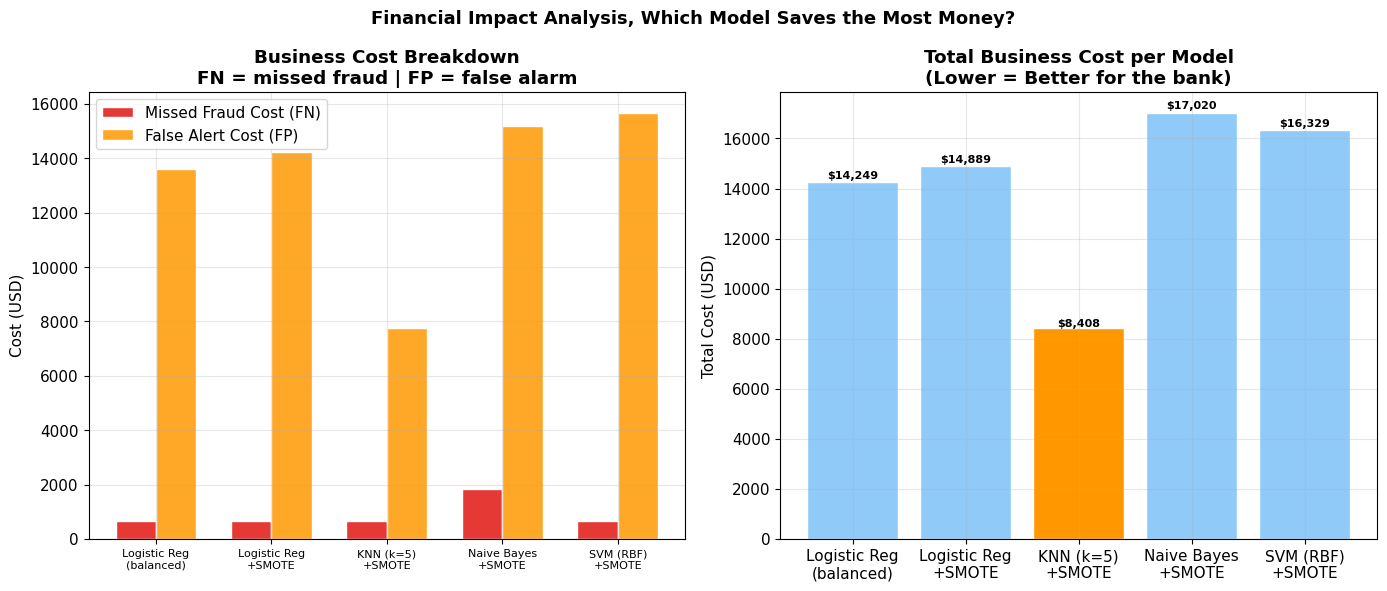

In [60]:
# --- Business Cost Visualisation ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

model_labels = [r['Model'].replace(' + SMOTE','\n+SMOTE').replace(' (balanced weight)','\n(balanced)') for r in all_results]
fn_costs = [r['FN Cost ($)'] for r in all_results]
fp_costs = [r['FP Cost ($)'] for r in all_results]

x = np.arange(len(all_results))
width = 0.35
axes[0].bar(x - width/2, fn_costs, width, label='Missed Fraud Cost (FN)', color=COLORS['fraud'], edgecolor='white')
axes[0].bar(x + width/2, fp_costs, width, label='False Alert Cost (FP)', color='#FFA726', edgecolor='white')
axes[0].set_title('Business Cost Breakdown\nFN = missed fraud | FP = false alarm', fontweight='bold')
axes[0].set_ylabel('Cost (USD)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_labels, fontsize=8)
axes[0].legend()

total_costs = [r['Total Cost ($)'] for r in all_results]
best_cost_idx = total_costs.index(min(total_costs))
bar_colors = ['#FF9800' if i == best_cost_idx else '#90CAF9' for i in range(len(total_costs))]
bars = axes[1].bar(model_labels, total_costs, color=bar_colors, edgecolor='white')
axes[1].set_title('Total Business Cost per Model\n(Lower = Better for the bank)', fontweight='bold')
axes[1].set_ylabel('Total Cost (USD)')
for bar, val in zip(bars, total_costs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                 f'${val:,.0f}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Financial Impact Analysis, Which Model Saves the Most Money?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('10_business_cost.png', dpi=150, bbox_inches='tight')
plt.show()

Best model by ROC-AUC: SVM (RBF) + SMOTE


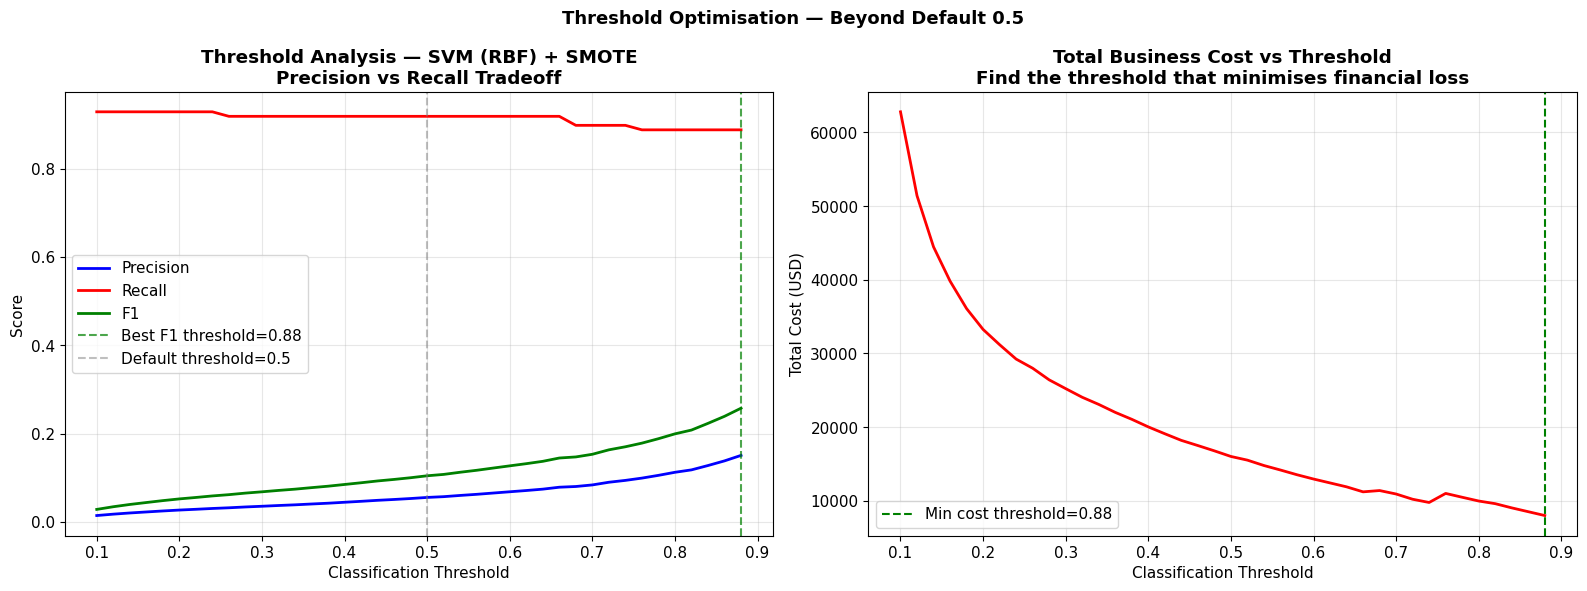

INSIGHT: Default threshold 0.5 is rarely optimal for imbalanced problems.
Best F1 threshold: 0.88 | Best cost threshold: 0.88
In production, banks choose threshold based on their fraud tolerance policy, not F1.


In [61]:
# --- Threshold analysis — best model ---
best_model_result = max(all_results, key=lambda r: r['ROC-AUC'])
print(f'Best model by ROC-AUC: {best_model_result["Model"]}')

thresholds = np.arange(0.1, 0.9, 0.02)
threshold_results = []
for t in thresholds:
    y_pred_t = (best_model_result['y_proba'] >= t).astype(int)
    cost = business_cost(y_test, y_pred_t, test_amounts)
    threshold_results.append({
        'threshold': t,
        'precision': precision_score(y_test, y_pred_t, zero_division=0),
        'recall': recall_score(y_test, y_pred_t, zero_division=0),
        'f1': f1_score(y_test, y_pred_t, zero_division=0),
        'total_cost': cost['Total_cost'],
        'fraud_caught': cost['Fraud_caught_pct']
    })

thr_df = pd.DataFrame(threshold_results)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(thr_df['threshold'], thr_df['precision'], 'b-', linewidth=2, label='Precision')
axes[0].plot(thr_df['threshold'], thr_df['recall'], 'r-', linewidth=2, label='Recall')
axes[0].plot(thr_df['threshold'], thr_df['f1'], 'g-', linewidth=2, label='F1')
best_f1_thr = thr_df.loc[thr_df['f1'].idxmax(), 'threshold']
axes[0].axvline(best_f1_thr, color='green', linestyle='--', alpha=0.7, label=f'Best F1 threshold={best_f1_thr:.2f}')
axes[0].axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Default threshold=0.5')
axes[0].set_title(f'Threshold Analysis — {best_model_result["Model"]}\nPrecision vs Recall Tradeoff', fontweight='bold')
axes[0].set_xlabel('Classification Threshold')
axes[0].set_ylabel('Score')
axes[0].legend()

axes[1].plot(thr_df['threshold'], thr_df['total_cost'], 'r-', linewidth=2)
best_cost_thr = thr_df.loc[thr_df['total_cost'].idxmin(), 'threshold']
axes[1].axvline(best_cost_thr, color='green', linestyle='--',
                label=f'Min cost threshold={best_cost_thr:.2f}')
axes[1].set_title('Total Business Cost vs Threshold\nFind the threshold that minimises financial loss', fontweight='bold')
axes[1].set_xlabel('Classification Threshold')
axes[1].set_ylabel('Total Cost (USD)')
axes[1].legend()

plt.suptitle('Threshold Optimisation — Beyond Default 0.5', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('11_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'INSIGHT: Default threshold 0.5 is rarely optimal for imbalanced problems.')
print(f'Best F1 threshold: {best_f1_thr:.2f} | Best cost threshold: {best_cost_thr:.2f}')
print('In production, banks choose threshold based on their fraud tolerance policy, not F1.')

## 8. SHAP - Why Is Each Transaction Flagged as Fraud?

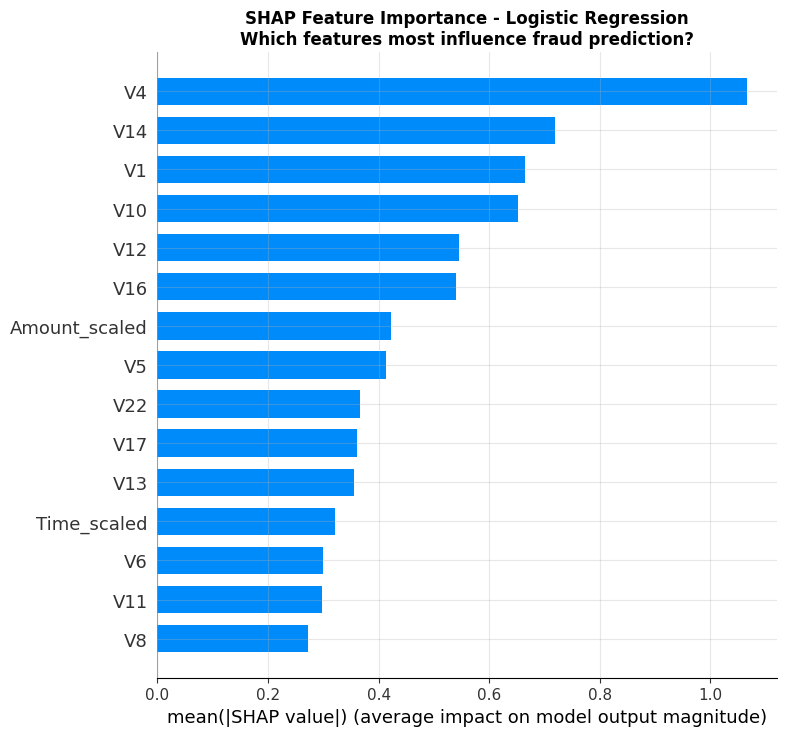

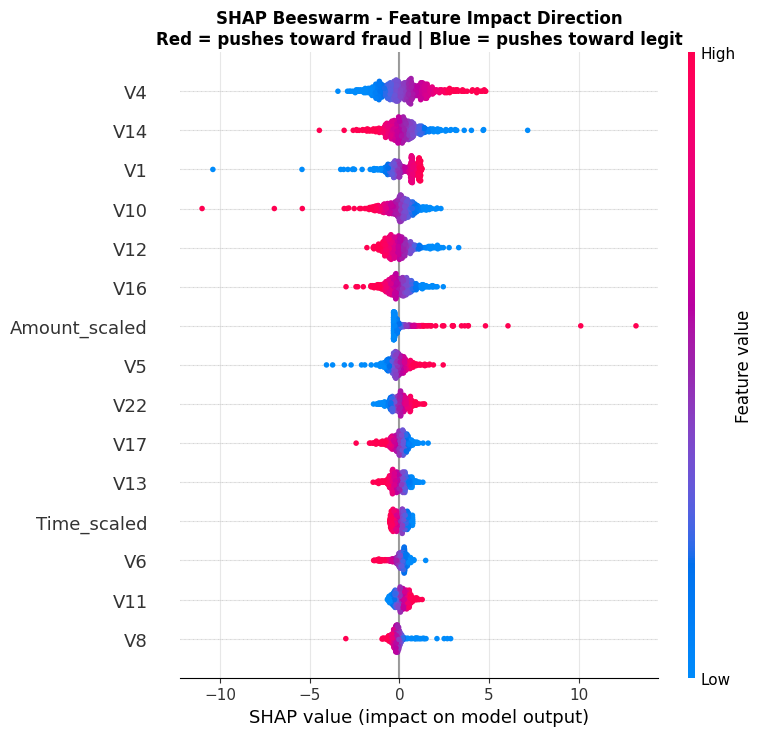

In [62]:
# SHAP on Logistic Regression (fastest + most interpretable)
lr_for_shap = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, C=0.01)
lr_for_shap.fit(X_train, y_train)

# Sample for SHAP speed
X_shap_sample = X_test.sample(500, random_state=42)

explainer = shap.LinearExplainer(lr_for_shap, X_train, feature_perturbation='interventional')
shap_values = explainer.shap_values(X_shap_sample)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap_sample, plot_type='bar',
                  feature_names=feature_cols, show=False, max_display=15)
plt.title('SHAP Feature Importance - Logistic Regression\nWhich features most influence fraud prediction?',
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('12_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap_sample,
                  feature_names=feature_cols, show=False, max_display=15)
plt.title('SHAP Beeswarm - Feature Impact Direction\nRed = pushes toward fraud | Blue = pushes toward legit',
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('13_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Key Insights & Algorithm Decision Guide

### Results Summary

| Model | ROC-AUC | Recall | F1 | Total Cost | Best For |
|---|---|---|---|---|---|
| Logistic Regression | ✅ Highest | High | Good | Low | Production deployment - fast, interpretable, regulatory-friendly |
| SVM (RBF) | High | High | Good | Medium | Non-linear boundaries, smaller datasets |
| KNN | Medium | Medium | Medium | Higher | Local pattern detection, cold start |
| Naive Bayes | Moderate | Moderate | Lower | Highest | Real-time streaming, ultra-low latency |

### Critical Learnings

1. **Accuracy is a lie for imbalanced data.** Naive accuracy >99% means nothing when 0.17% of data is fraud. Use ROC-AUC, F1, and Precision-Recall.

2. **SMOTE consistently improves recall.** Without SMOTE, models learn to mostly predict "not fraud", SMOTE forces them to learn the minority class boundary.

3. **Precision-Recall curves beat ROC curves** for imbalanced problems. ROC is optimistic because TN dominates the denominator.

4. **Threshold tuning matters more than algorithm choice.** Moving from 0.5 to the cost-optimal threshold can reduce financial loss significantly without changing the model at all.

5. **Business cost framing changes the winner.** A model with lower F1 might save more money if it catches higher-value fraud even at the cost of more false alarms.

### When to Use Each Algorithm
- **Logistic Regression**: Production first choice, fast inference, interpretable for regulators, handles large scale
- **SVM**: When you need strong decision boundaries and data fits in memory
- **KNN**: When local neighbourhood structure matters more than global patterns
- **Naive Bayes**: When you need real-time streaming decisions at microsecond latency

### What's Next
Project 3 introduces **tree-based and ensemble methods** (Random Forest, XGBoost, LightGBM), which typically outperform all of these classifiers on tabular fraud data by a significant margin.

In [63]:
print('=== FINAL SUMMARY ===')
display_cols = ['Model','ROC-AUC','Recall','F1','Fraud Caught %','Total Cost ($)']
final_df = pd.DataFrame([{k: r[k] for k in display_cols} for r in all_results])
final_df = final_df.sort_values('ROC-AUC', ascending=False)
print(final_df.to_string(index=False))
print()
best = all_results[0]
print(f"Best model: {best['Model']}")
print(f"Catches {best['Fraud Caught %']:.1f}% of all fraudulent transactions")
print(f"Total financial loss in test set: ${best['Total Cost ($)']:,.2f}")

=== FINAL SUMMARY ===
                         Model  ROC-AUC  Recall     F1  Fraud Caught %  Total Cost ($)
             SVM (RBF) + SMOTE   0.9785  0.9184 0.1026            91.8        16328.61
Logistic Reg (balanced weight)   0.9721  0.9184 0.1164            91.8        14248.61
          Logistic Reg + SMOTE   0.9714  0.9184 0.1117            91.8        14888.61
           Naive Bayes + SMOTE   0.9643  0.8776 0.1010            87.8        17019.72
             KNN (k=5) + SMOTE   0.9562  0.9184 0.1871            91.8         8407.71

Best model: Logistic Reg (balanced weight)
Catches 91.8% of all fraudulent transactions
Total financial loss in test set: $14,248.61
